**Connect to git repo + install requirements**

In [1]:
import os

#check if the repository folder already exists on the colab disk
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    %cd /content/QML4EO-reproduction
    !git pull
else:
    print("Cloning repo for the first time..")
    %cd /content
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    %cd QML4EO-reproduction

#install required dependencies
!pip install -r requirements.txt -q

Cloning repo for the first time..
/content
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 80 (delta 28), reused 68 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 6.99 MiB | 15.81 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/QML4EO-reproduction
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
from src.baselines.cnn import set_seed, train_baseline
from src.utils.data_loader import get_eurosat_dataloaders
from src.models.hqcnn import HybridQCNN

#setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized: {device}")

Hardware utilized: cuda


**Load Data**

In [3]:
#load data
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

Downloading/Loading EuroSAT dataset into ./data...


100%|██████████| 94.3M/94.3M [00:01<00:00, 67.5MB/s]


Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### **Experiment 1: Qubit Scaling**

We'll experiment to test how the number of qubits (the size of the information bottleneck) impacts the learning capacity of HQCNN

#### **Qubit Scaling & The Information Bottleneck**

We'll test how the size of the quantum state affects the model's ability to represent EuroSAT features. We'll skip 4 qubits because we already locked in that hqcnn baseline (~66% accuracy).

We avoid testing 10 or more qubits due to the exponential memory limits of simulating quantum states classically.

* **2 Qubits:** Establishes the absolute floor. We expect a 2-qubit bottleneck to destroy too much spatial information.
* **6 and 8 Qubits:** Pushes the ceiling. We want to measure the exact accuracy gained for every additional pair of simulated qubits.

**Note:** Each configuration is tested across 3 random seeds for 15 epochs to ensure observations are statistically solid.

In [4]:
import numpy as np

#define the variations and rigor parameters
qubit_configs = [2, 6, 8]
SEEDS = [42, 100, 2026]
EPOCHS = 15

#dictionaries to store data for analysis and plotting
ablation_results = {}
qubit_histories = {}

print("Starting Rigorous Qubit Scaling Ablation Study...")

for qubits in qubit_configs:
    print(f"\n CONFIGURATION: {qubits} QUBITS (1 Ansatz Layer) ")

    seed_accs = []
    total_params = 0

    for seed in SEEDS:
        print(f"\n Testing Seed {seed} ")
        set_seed(seed)

        #initialize fresh model for this config
        model = HybridQCNN(num_classes=len(classes), num_qubits=qubits, num_layers=1)
        model = model.to(device)

        #calculate parameters (only needs to be done once per config)
        if total_params == 0:
            total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"Total Trainable Parameters: {total_params:,}")

        #run training
        history = train_baseline(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            lr=0.001,
            device=device
        )

        seed_accs.append(history['val_acc'])

    #calculate statistics for this qubit configuration
    acc_array = np.array(seed_accs)
    mean_acc = np.mean(acc_array, axis=0)
    std_acc = np.std(acc_array, axis=0)

    qubit_histories[qubits] = {'mean': mean_acc, 'std': std_acc}
    ablation_results[f"{qubits}_qubits"] = {
        "params": total_params,
        "final_mean": mean_acc[-1],
        "final_std": std_acc[-1]
    }

print("\nQubit Scaling Study Complete! ")
print("Summary of Results (Mean ± Std Dev):")
for config, metrics in ablation_results.items():
    print(f"{config}: Parameters={metrics['params']}, Final Accuracy={metrics['final_mean']:.2f}% ± {metrics['final_std']:.2f}%")

Starting Rigorous Qubit Scaling Ablation Study...

 CONFIGURATION: 2 QUBITS (1 Ansatz Layer) 

 Testing Seed 42 
Total Trainable Parameters: 5,186


Epoch 1/15 [Train]: 100%|██████████| 675/675 [00:22<00:00, 30.25it/s, loss=1.8722]


Epoch 1 Summary -> Train Loss: 2.0886 | Val Accuracy: 34.39%


Epoch 2/15 [Train]: 100%|██████████| 675/675 [00:20<00:00, 32.19it/s, loss=1.5945]


Epoch 2 Summary -> Train Loss: 1.7857 | Val Accuracy: 39.85%


...

Epoch 13 Summary -> Train Loss: 0.8917 | Val Accuracy: 64.30%


Epoch 14/15 [Train]: 100%|██████████| 675/675 [00:40<00:00, 16.50it/s, loss=0.9681]


Epoch 14 Summary -> Train Loss: 0.8653 | Val Accuracy: 67.69%


Epoch 15/15 [Train]: 100%|██████████| 675/675 [00:40<00:00, 16.47it/s, loss=1.1100]


Epoch 15 Summary -> Train Loss: 0.8513 | Val Accuracy: 65.98%

Qubit Scaling Study Complete! 
Summary of Results (Mean ± Std Dev):
2_qubits: Parameters=5186, Final Accuracy=49.56% ± 1.62%
6_qubits: Parameters=5362, Final Accuracy=70.25% ± 1.75%
8_qubits: Parameters=5450, Final Accuracy=69.83% ± 2.78%


**Analysis: Information Bottleneck and Exponential Cost**

Our qubit scaling experiment reveals three key insights about quantum-classical architectures:

* **The Severe Bottleneck (2 Qubits):** Squeezing 32 classical feature channels into a 2-qubit state destroys too much spatial information. The model produced a baseline accuracy of just 49.56% ± 1.62%.
* **The Expressivity Plateau (6 vs 8 Qubits):**
  * Expanding the bottleneck from 2 to 6 qubits caused a massive accuracy jump to 70.25% ± 1.75%.
  * However, expanding further to 8 qubits yielded no additional gain (69.83% ± 2.78%), proving that a 1-layer ansatz struggles to navigate the vastly larger 256-dimensional space of an 8-qubit system within 15 epochs.
* **The Simulation Wall:**
  * Training speed dropped exponentially. The 2-qubit model ran at ~33 iterations per second (it/s), the 6-qubit at ~21 it/s, and the 8-qubit at just ~16 it/s.
  * This drop physically proves the exponential memory and compute cost of simulating quantum state vectors on classical T4 GPUs.

**Visualization**

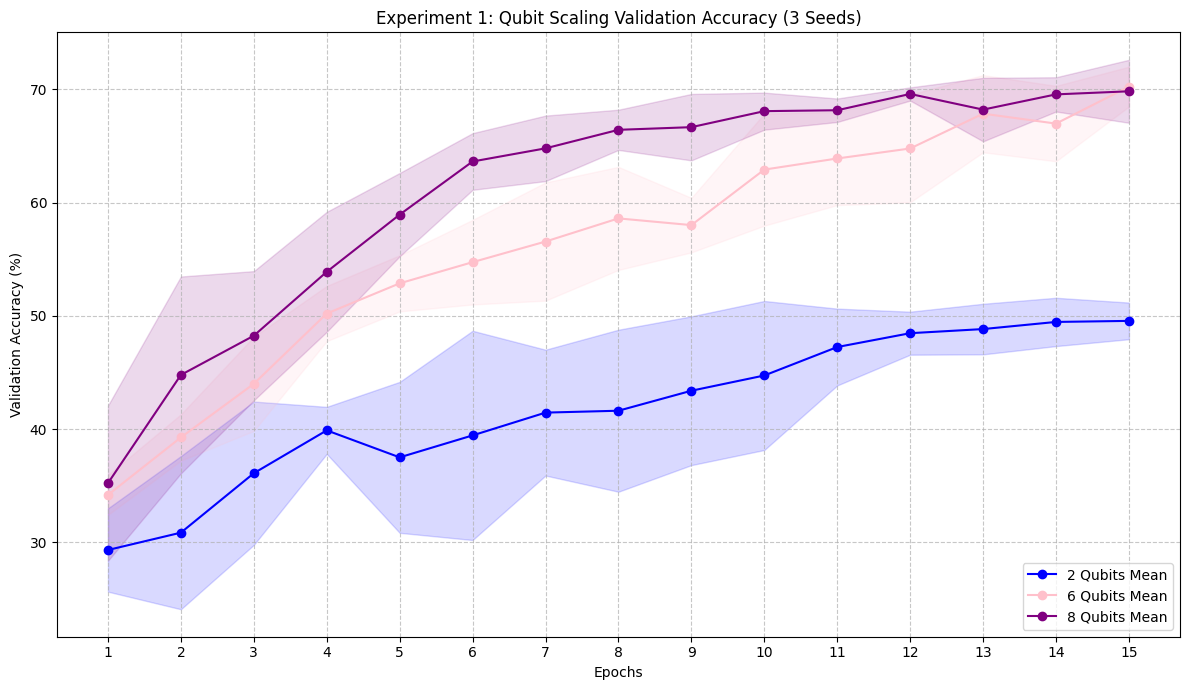

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 7))
colors = {2: 'blue', 6: 'pink', 8: 'purple'}
epochs_range = range(1, EPOCHS + 1)

for qubits, data in qubit_histories.items():
    mean_acc = data['mean']
    std_acc = data['std']

    plt.plot(epochs_range, mean_acc, label=f'{qubits} Qubits Mean', color=colors[qubits], marker='o')
    plt.fill_between(
        epochs_range,
        mean_acc - std_acc,
        mean_acc + std_acc,
        color=colors[qubits],
        alpha=0.15
    )

plt.title('Experiment 1: Qubit Scaling Validation Accuracy (3 Seeds)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(epochs_range)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()